In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.api as smt

### Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.


In [61]:
pd.read_csv('exchange_rate.csv').head(),pd.read_csv('exchange_rate.csv').tail()

(               date  Ex_rate
 0  01-01-1990 00:00   0.7855
 1  02-01-1990 00:00   0.7818
 2  03-01-1990 00:00   0.7867
 3  04-01-1990 00:00   0.7860
 4  05-01-1990 00:00   0.7849,
                   date   Ex_rate
 7583  06-10-2010 00:00  0.718494
 7584  07-10-2010 00:00  0.721839
 7585  08-10-2010 00:00  0.723197
 7586  09-10-2010 00:00  0.720825
 7587  10-10-2010 00:00  0.720825)

In [62]:
pd.read_csv('exchange_rate.csv').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [63]:
df = pd.read_csv(
    'exchange_rate.csv',
    parse_dates=['date'],
    date_parser=lambda x: pd.to_datetime(x, format="%d-%m-%Y %H:%M"),
    index_col='date'
)
df.head

<bound method NDFrame.head of              Ex_rate
date                
1990-01-01  0.785500
1990-01-02  0.781800
1990-01-03  0.786700
1990-01-04  0.786000
1990-01-05  0.784900
...              ...
2010-10-06  0.718494
2010-10-07  0.721839
2010-10-08  0.723197
2010-10-09  0.720825
2010-10-10  0.720825

[7588 rows x 1 columns]>

In [64]:
## missing values
df.isnull().sum()

Ex_rate    0
dtype: int64

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


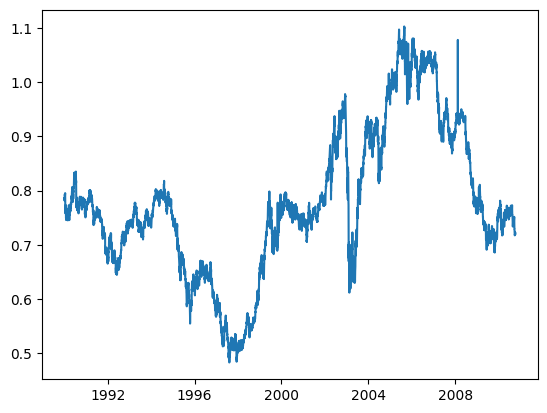

In [66]:
plt.plot(df)

<Axes: xlabel='date'>

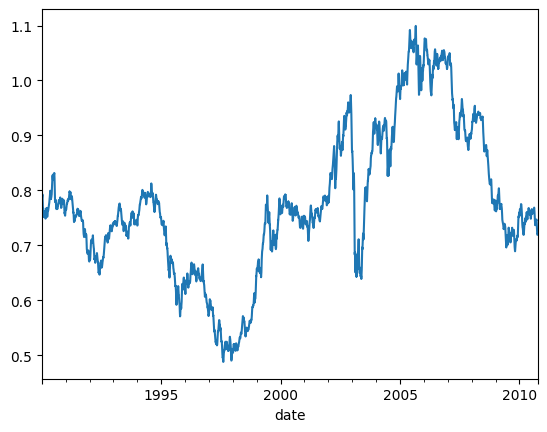

In [96]:
result= seasonal_decompose(df['Ex_rate'],model='additive')
result.trend.plot()

<Axes: xlabel='date'>

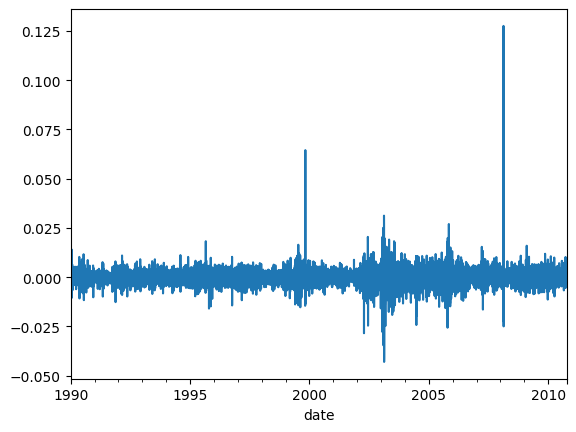

In [69]:
result.resid.plot()

### Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


In [70]:
df = pd.read_csv(
    'exchange_rate.csv',
    parse_dates=['date'],
    date_parser=lambda x: pd.to_datetime(x, format="%d-%m-%Y %H:%M"),
    index_col='date'
)
df.head

<bound method NDFrame.head of              Ex_rate
date                
1990-01-01  0.785500
1990-01-02  0.781800
1990-01-03  0.786700
1990-01-04  0.786000
1990-01-05  0.784900
...              ...
2010-10-06  0.718494
2010-10-07  0.721839
2010-10-08  0.723197
2010-10-09  0.720825
2010-10-10  0.720825

[7588 rows x 1 columns]>

In [71]:
def test_stationarity(timeseries):

    #Calculate rolling mean and rolling standard deviation
    rolmean = timeseries.rolling(window = 2).mean()
    rolstd = timeseries.rolling(window = 2).std()

    original = plt.plot(timeseries, color = 'blue', label = 'Original')
    mean = plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
    std = plt.plot(rolstd, color = 'green', label = 'Rolling Std')
    plt.legend(loc='best')


    print('Results of Dickey-Fuller Test :\n')
    df_test = adfuller(timeseries)
    my_output = pd.Series(df_test[0:4], index =['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for i,j in df_test[4].items():
        my_output['Critical Value (%s)'%i] =j
    print(my_output)

Results of Dickey-Fuller Test :

Test Statistic                   -1.664994
p-value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


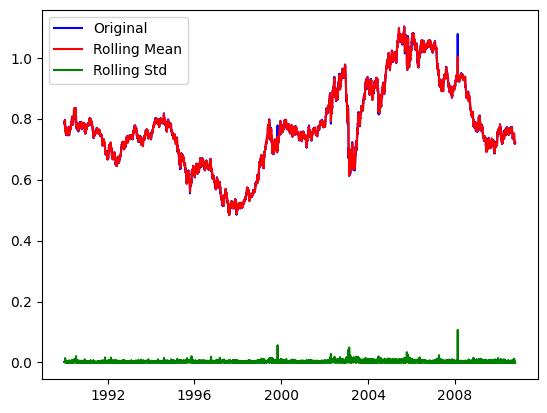

In [72]:
test_stationarity(df['Ex_rate'])

### Differencing

In [73]:
df['df_Diff']= df['Ex_rate']-df['Ex_rate'].shift(1)

In [74]:
df

,Ex_rate,df_Diff
date,,
1990-01-01,0.785500,NaN
1990-01-02,0.781800,-0.003700
1990-01-03,0.786700,0.004900
1990-01-04,0.786000,-0.000700
1990-01-05,0.784900,-0.001100
...,...,...
2010-10-06,0.718494,-0.000207
2010-10-07,0.721839,0.003345
2010-10-08,0.723197,0.001358


In [75]:
df.dropna(inplace=True)

In [76]:
df

,Ex_rate,df_Diff
date,,
1990-01-02,0.781800,-0.003700
1990-01-03,0.786700,0.004900
1990-01-04,0.786000,-0.000700
1990-01-05,0.784900,-0.001100
1990-01-06,0.786600,0.001700
...,...,...
2010-10-06,0.718494,-0.000207
2010-10-07,0.721839,0.003345
2010-10-08,0.723197,0.001358


Results of Dickey-Fuller Test :

Test Statistic                  -99.393431
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


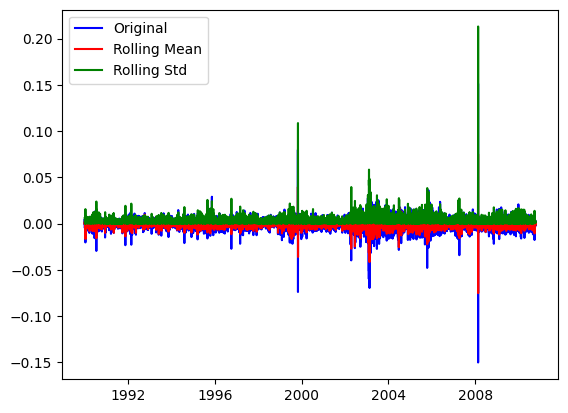

In [77]:
test_stationarity(df['df_Diff'])

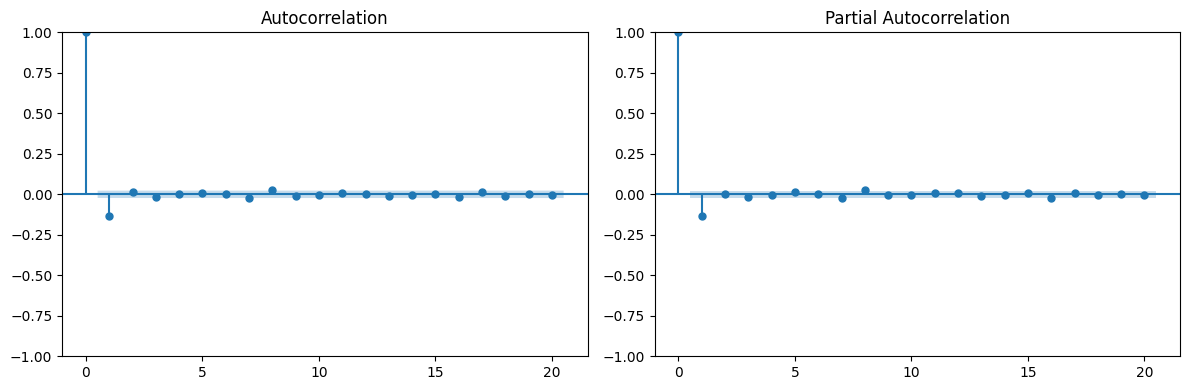

In [78]:
fig,axes =plt.subplots(1,2)
fig.set_figwidth(12)
fig.set_figheight(4)
smt.graphics.plot_acf(df['df_Diff'],lags=20 ,ax=axes[0])
smt.graphics.plot_pacf(df['df_Diff'],lags=20 ,ax=axes[1])
plt.tight_layout()


In [79]:
import warnings
warnings.filterwarnings('ignore')
model = ARIMA(df['Ex_rate'], order=(1,1,1))

In [80]:
df.columns

Index(['Ex_rate', 'df_Diff'], dtype='object')

In [81]:
df.head()

,Ex_rate,df_Diff
date,,
1990-01-02,0.7818,-0.0037
1990-01-03,0.7867,0.0049
1990-01-04,0.7860,-0.0007
1990-01-05,0.7849,-0.0011
1990-01-06,0.7866,0.0017


In [82]:
result= model.fit()
result.predict()

1990-01-02    0.000000
1990-01-03    0.781800
1990-01-04    0.786056
1990-01-05    0.786089
1990-01-06    0.785045
                ...   
2010-10-06    0.718837
2010-10-07    0.718522
2010-10-08    0.721400
2010-10-09    0.723017
2010-10-10    0.721136
Freq: D, Name: predicted_mean, Length: 7587, dtype: float64

In [83]:
result.forecast(10)

2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
2010-10-16    0.720826
2010-10-17    0.720826
2010-10-18    0.720826
2010-10-19    0.720826
2010-10-20    0.720826
Freq: D, Name: predicted_mean, dtype: float64

In [84]:
df['predicted']=result.predict()

In [85]:
df.head()

,Ex_rate,df_Diff,predicted
date,,,
1990-01-02,0.7818,-0.0037,0.000000
1990-01-03,0.7867,0.0049,0.781800
1990-01-04,0.7860,-0.0007,0.786056
1990-01-05,0.7849,-0.0011,0.786089
1990-01-06,0.7866,0.0017,0.785045


In [86]:
forecast=result.forecast(20)
forecast

2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
2010-10-16    0.720826
2010-10-17    0.720826
2010-10-18    0.720826
2010-10-19    0.720826
2010-10-20    0.720826
2010-10-21    0.720826
2010-10-22    0.720826
2010-10-23    0.720826
2010-10-24    0.720826
2010-10-25    0.720826
2010-10-26    0.720826
2010-10-27    0.720826
2010-10-28    0.720826
2010-10-29    0.720826
2010-10-30    0.720826
Freq: D, Name: predicted_mean, dtype: float64

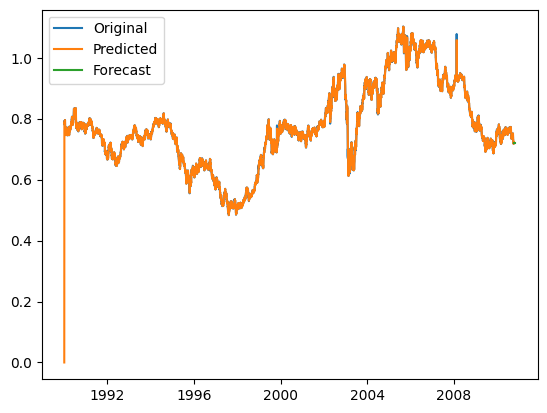

In [87]:
plt.plot(df['Ex_rate'],label='Original')
plt.plot(df['predicted'],label='Predicted')
plt.plot(forecast,label='Forecast')
plt.legend()

### Part 3: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


In [88]:
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error,mean_absolute_error

In [94]:
MAE=mean_absolute_error(df['Ex_rate'],df['predicted'])
MAPE=mean_absolute_percentage_error(df['Ex_rate'],df['predicted'])
RMSE=mean_squared_error(df['Ex_rate'],df['predicted'])
print("MAE:", MAE)
print("MAPE:",MAPE)
print("RMSE:", RMSE)

MAE: 0.0037954612722953603
MAPE: 0.0049514654415826875
RMSE: 0.00011651556649649994
